In [1]:
import sys
sys.path.append('../')
from pprint import pprint

import itertools
import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from finite_groups import FiniteGroup
from induced_rep_solver import InducedRepSolver
from symchar.symchar import character_table

from groups.irrep_mats_generators import irreps_mats_D2n

def RELU(x): return sp.Max(0, x)
def TANH(x): return sp.tanh(x)
def SIGMOID(x): return 1 / (1 + sp.exp(-x))
def LINEAR(x): return x
def SQUARE(x): return x**2
def RELU_TANH(x): return RELU(x) + TANH(x)

# Utils

In [2]:
def build_D2n(n: int) -> FiniteGroup:
    """
    Dihedral group of order 2n.

    Elements are pairs (k, e) with 0 <= k < n and e in {0,1}, representing
        r^k           if e = 0,
        r^k s         if e = 1,
    with relations r^n = 1, s^2 = 1, srs = r^{-1}.
    """
    if n < 2:
        raise ValueError("n must be >= 2")

    elements = [(k, e) for k in range(n) for e in (0, 1)]

    def mult(x, y):
        a, e = x
        b, f = y
        # (r^a s^e)(r^b s^f) = r^{a + (-1)^e b} s^{e+f}
        return ((a + ((-1) ** e) * b) % n, (e + f) % 2)

    return FiniteGroup(elements, mult)


def build_H() -> list[tuple[int, int]]:
    # H = <s> = {1, s}
    return [(0, 0), (0, 1)]


## Characters

In [3]:
def generate_partitions(n):
    def generate(n, max_part, current, result):
        if n == 0:
            result.append(tuple(current))
            return
        for i in range(min(max_part, n), 0, -1):
            generate(n - i, i, current + [i], result)

    result = []
    generate(n, n, [], result)
    return result

def dihedral_character_table_map(G: FiniteGroup, n: int):
    """
    Returns (class_char_map, labels) for D_{2n}.

    Values are given on class representatives discovered by FiniteGroup.
    """
    labels = []
    irrep_value_funcs = []

    if n % 2 == 1:
        # Two 1D irreps: r -> 1, s -> ±1
        for eps in (1, -1):
            labels.append(rf"$\chi_{{1,{1 if eps == 1 else -1}}}$")
            irrep_value_funcs.append(
                lambda g, eps=eps: sp.Integer(1) if g[1] == 0 else sp.Integer(eps)
            )

        # (n-1)/2 two-dimensional irreps
        for m in range(1, (n - 1) // 2 + 1):
            labels.append(rf"$\rho_{{{m}}}$")

            def char(g, m=m):
                k, e = g
                if e == 1:
                    return sp.Integer(0)
                return sp.simplify(2 * sp.cos(2 * sp.pi * m * k / n))

            irrep_value_funcs.append(char)
    else:
        # Four 1D irreps determined by r -> a, s -> b with a,b in {±1}
        for a in (1, -1):
            for b in (1, -1):
                labels.append(rf"$\chi_{{r={a},s={b}}}$")

                def char(g, a=a, b=b):
                    k, e = g
                    if e == 0:
                        return sp.Integer(a**k)
                    return sp.Integer((a**k) * b)

                irrep_value_funcs.append(char)

        # n/2 - 1 two-dimensional irreps
        for m in range(1, n // 2):
            labels.append(rf"$\rho_{{{m}}}$")

            def char(g, m=m):
                k, e = g
                if e == 1:
                    return sp.Integer(0)
                return sp.simplify(2 * sp.cos(2 * sp.pi * m * k / n))

            irrep_value_funcs.append(char)

    class_char_map = {}
    for cls in G.classes:
        rep = cls.representative
        class_char_map[rep] = [sp.simplify(f(rep)) for f in irrep_value_funcs]

    return class_char_map, labels

def cycle_type(perm):
    k = len(perm)
    seen = [False]*k
    parts = []

    for i in range(k):
        if not seen[i]:
            j=i
            length=0
            while not seen[j]:
                seen[j]=True
                j=perm[j]
                length+=1
            parts.append(length)

    return tuple(sorted(parts, reverse=True))

def run(G,H,n, activation_fn, 
        refine=False, 
        regular=False, 
        irrep_mats=None, 
        interaction=False,
        figsize=(10,10)):

    solver = InducedRepSolver(G)
    if regular:
        solver.set_subgroup([G.identity])
    else:
        solver.set_subgroup(H)

    class_char_map, labels = dihedral_character_table_map(G, n)

    solver.load_character_table(class_char_map, labels)

    if refine:
        irrep_mats = irreps_mats_D2n(n)
        solver.load_irrep_matrices(irrep_mats)

    solver.compute_projectors(refine=refine)

    if interaction:
        graph = solver.build_interaction_graph(activation_fn=activation_fn)
    else:
        graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    solver.visualise_interaction_graph(
        graph,
        group_name=rf"$D_{{2 \cdot {n}}} \quad (\text{{{activation_fn.__name__}}})$",
        node_size=2200,
        show_self_loops=False,
        figsize=figsize,
    )

    return graph, solver

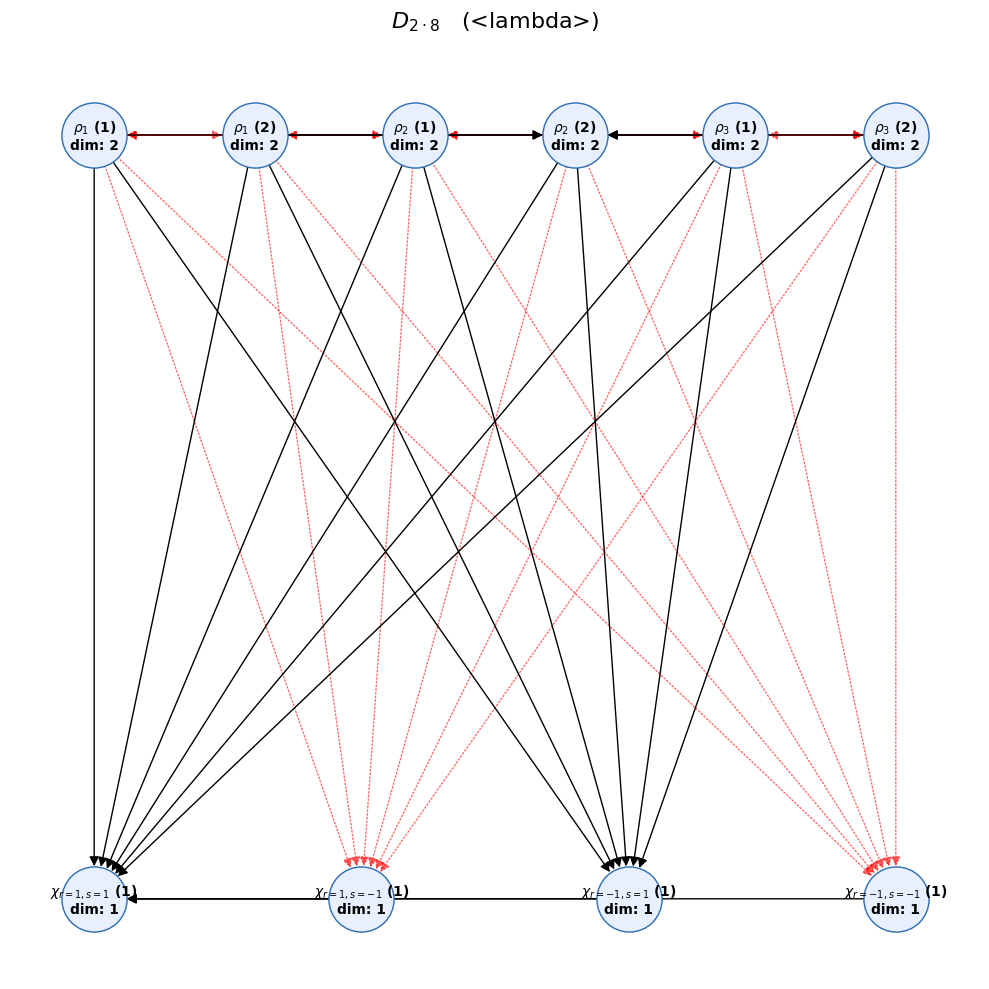

In [9]:
n = 8

activation_fn = lambda x: sp.Abs(x)
regular = True
refine = True
interaction = True

if interaction:
    refine = True

G = build_D2n(n)
H = build_H()

graph, solver = run(G, H, n, activation_fn, regular=regular, refine=refine, interaction=interaction)

In [7]:
sp.Matrix(nx.to_numpy_array(graph).astype(int))

Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
[1, 1, 1, 1, 0, 0, 1, 1, 0, 0],
[1, 1, 1, 1, 0, 0, 1, 1, 0, 0],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

In [6]:
col_ranges = {}
col_labels = []

start = 0
blocks = []

for label, Qblock in solver.Qblocks.items():
    r, c = Qblock.shape
    if r > 1:                      
        blocks.append(Qblock)

        end = start + c
        col_ranges[label] = (start, end)
        col_labels.extend([label] * c)
        start = end


Q = sp.Matrix(np.hstack(blocks))
Q_inv = Q.inv()


pprint(col_ranges)
# sp.Matrix([0,1,0,0,0,0,0,0]).T * Q_inv * (Q * sp.Matrix([0,0,0,0,1,1,0,0])).applyfunc(activation_fn)
Q_inv * (Q).applyfunc(activation_fn)

{'$\\chi_{r=-1,s=-1}$': (3, 4),
 '$\\chi_{r=-1,s=1}$': (2, 3),
 '$\\chi_{r=1,s=-1}$': (1, 2),
 '$\\chi_{r=1,s=1}$': (0, 1),
 '$\\rho_{1}$': (4, 8),
 '$\\rho_{2}$': (8, 12),
 '$\\rho_{3}$': (12, 16)}


Matrix([
[0,                  -0.5,                  -0.5,                  -0.5,    -0.301776695296637,    -0.307031793451068,    -0.301776695296637,    -0.307031793451068,                 -0.25,                 -0.25, -0.25,                -0.25,    -0.301776695296637,    -0.307031793451068,    -0.301776695296637,    -0.307031793451068],
[0,                   0.5, -1.38777878078145e-17,  3.46944695195361e-17,    -0.301776695296637,     0.307031793451068,    -0.301776695296637,     0.307031793451068,                  0.25,                  0.25, -0.25,                -0.25,    -0.301776695296637,     0.307031793451068,    -0.301776695296637,     0.307031793451068],
[0, -6.24500451351651e-17,                   0.5, -5.55111512312578e-17,    0.0517766952966369,    0.0461725543782535,    0.0517766952966369,    0.0461725543782534,                 -0.25,                  0.25,  0.25,                -0.25,    0.0517766952966368,    0.0461725543782534,    0.0517766952966369,    0.04617255437

In [12]:
def run(n,k, activation=RELU, Cn_labels=None):

    G = build_D2n(n)
    H = build_H()

    solver = InducedRepSolver(G)
    solver.set_subgroup(H)

    class_char_map, labels = dihedral_character_table_map(G, n)

    solver.load_character_table(class_char_map, labels)
    solver.compute_projectors(refine=False)

    # graph = solver.build_interaction_graph(activation_fn=activation_fn)
    graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    return graph, solver

In [13]:
graphs = {}
n = 4
activation_fn = RELU

for i in range(1, n+1):
    for j in range(1, n+1):
        print(f"Computing C{i+1} x S{j+1}")
        graphs[(i, j)] = run(i, j, activation=activation_fn)

def create_svg_grid(graphs, n, filename="grid.svg"):

    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            graph, solver = graphs[(i+1, j+1)]
            solver.visualise_interaction_grid(graph, ax=ax, group_name=f"C{i+1} x S{j+1}")


    plt.tight_layout()
    fig.savefig(filename, format="svg")
    plt.close(fig)


create_svg_grid(graphs, n=n, filename=f"outputs/Regular_Cn_Sk_n={n}_{activation_fn.__name__}.svg")

Computing C2 x S2


ValueError: n must be >= 2